### Revisão básica de Variáveis complexas
---
O número complexo é amplamente usado na engenharia, assim antes de iniciarmos os estudos faremos uma pequena revisão.

Um número complexo é formado por uma parte real e por uma parte imaginária e geralmente representada pela letra $z$. Uma variável complexa é expressa da seguinte forma:

$$ z = x + yi$$
onde a unidade imaginária as vezes é representada pela letra $j$.

> Algumas Observações:
+ $x:$ é a parte real de $z$, denotada por $Re(z)$.
+ $yi:$ é a parte imaginária de $z$, denotada por $Im(z)$.
+ Propriedade da unidade imaginária: $i^2 = -1$.
+ __Forma Polar:__ $z = re^{iθ} = r(cosθ + isenθ)$, onde $r = |z| = \sqrt{x^2 + y^2}$

Se tomarmos o $θ$ variando no tempo, podemos ter $θ = wt$. Utilizando a identidade de *Euler*, podemos escrever da seguinte forma:

$$ e^{jwt} = (cos(wt) + j sen(wt))$$
Onde podemos retirar as seguintes expressões:
$$cos(wt) = Re(e^{jwt})$$
$$sen(wt) = Im(e^{jwt})$$

### Análise de sinais
---
Essencialmente, um sinal é uma representação matemática de uma variável física que carrega informações sobre um sistema ou processo. A análise de sinais permite extrair informações relevantes desses dados e, assim, entender melhor o comportamento de fenômenos naturais ou artificiais, desenvolver tecnologias de comunicação e aprimorar sistemas de controle e monitoramento.

Os sinais podem ser classificados em várias categorias, sendo as mais comuns os sinais contínuos e os sinais discretos. Sinais contínuos variam de forma contínua ao longo do tempo e são característicos de fenômenos naturais, como ondas de áudio ou eletromagnéticas. Já os sinais discretos são amostragens de sinais contínuos em intervalos específicos de tempo e são amplamente utilizados em sistemas digitais, como computadores e dispositivos de comunicação.

> __Sinais contínuos:__ denonato como x(t), é uma função (real ou complexa) cujo domínio é o conjunto dos reais ℝ. Sinais contínuos representam fenômenos físicos naturais, como som, temperatura e luz, que têm variação contínua em vez de saltos entre valores discretos.

> __Sinais discretos:__ denotado como x[n], é uma função (real ou complexa) cujo domínio é o conjunto dos inteiros 𝒁. Um sinal discreto pode representar um fenômeno para o qual a variável independente é inerentemente discreta. Sinais como dados demográficos são exemplos de tal caso. Por outro lado, uma classe muito importante de sinais de tempo discreto decorre da amostragem de sinais de tempo contínuo.


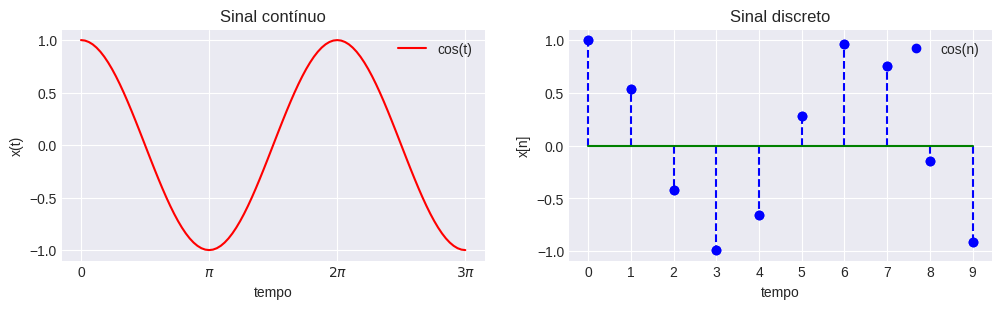

In [110]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 3*np.pi, 100)
n = np.arange(0, 3*np.pi, 1)
x = np.cos(t)
y = lambda n: np.cos(n)

# Configurando o gráfico.
plt.style.use('seaborn-v0_8-darkgrid')
fig, axis = plt.subplots(1, 2, figsize = (12,3))

#
axis[0].plot(t, x, color = "red", label = "cos(t)")
axis[0].set_xticks([0, np.pi, 2 * np.pi, 3 * np.pi], [r'0', r'$\pi$', r'$2\pi$', r'$3\pi$'])
axis[0].set_xlabel("tempo")
axis[0].set_ylabel("x(t)")
axis[0].set_title("Sinal contínuo")
axis[0].legend(loc = "best")

# Sinal discreto
axis[1].plot(n, y(n), "o", color = "blue", label = "cos(n)")
axis[1].stem(n, y(n), linefmt='b--', basefmt='g-')
axis[1].set_xticks(np.arange(0, 3*np.pi, 1))
axis[1].set_xlabel("tempo")
axis[1].set_ylabel("x[n]")
axis[1].set_title("Sinal discreto")
axis[1].legend(loc = "best")

plt.show()

No primeiro subplot, apresentamos um gráfico senoidal que é perfeito para ilustrar um sinal contínuo. Ele mostra a distribuição cossenoidal do sinal ao longo do tempo $t$, permitindo que a forma da onda completa seja claramente observada. Esse sinal varia continuamente no intervalo de $[0,3π]$. No segundo subplot, utilizamos `axis[1].stem`, que gera um gráfico com hastes. Esse tipo de gráfico é perfeito para ilustrar como funciona um sinal discreto, pois destaca que o sinal existe apenas em pontos específicos. Isso é especialmente útil para mostrar sinais amostrados ou sequências numéricas.

Esses gráficos possibilitam uma comparação direta entre a representação contínua e a discreta. Eles oferecem uma visualização clara e didática, facilitando a compreensão da transição de um sinal contínuo para o discreto.

### Manipulações com sinais periódicos
Um sinal periódico de tempo contínuo $x(t)$ tem a propriedade de que existe um valor positivo T para o qual $x(t) = x(t + T)$ para todos os valores de $t$. Em outras palavras, um sinal periódico tem a propriedade de não se modificar pelo deslocamento no tempo de $T$.

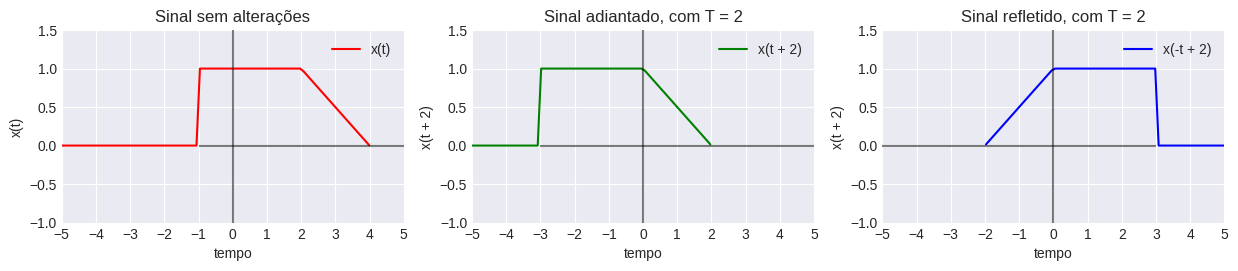

In [ ]:
def x(t):
    if t < -1:
        return 0
    elif(t <= 2):
        return 1
    elif(t <= 4):
        return 2 - 0.5 * t

t = np.linspace(-5, 5, 100)

fig, axis = plt.subplots(1, 3, figsize = (15, 2.5))

# Sinal sem alterações
axis[0].plot(t, list(map(x, t)), color = "red", label = "x(t)")
axis[0].axis([-5, 5, -1, 1.5])
axis[0].set_xticks(np.arange(-5, 6, 1))
axis[0].hlines(0, -1, 5, 'k', alpha=0.5)
axis[0].vlines(0, -1, 1.5, 'k', alpha=0.5)
axis[0].set_title("Sinal sem alterações")
axis[0].legend(loc = "best")
axis[0].set_xlabel("tempo")
axis[0].set_ylabel("x(t)")

# Sinal adiantado, com T = 2
axis[1].plot(t, list(map(x, t + 2)), color = "green", label = "x(t + 2)")
axis[1].axis([-5, 5, -1, 1.5])
axis[1].set_xticks(np.arange(-5, 6, 1))
axis[1].hlines(0, -3, 5, "k", alpha = 0.5)
axis[1].vlines(0, -1, 1.5, "k", alpha = 0.5)
axis[1].set_title("Sinal adiantado, com T = 2")
axis[1].set_xlabel("tempo")
axis[1].set_ylabel("x(t + 2)")
axis[1].legend(loc = "best")

# Sinal refletido, com T = 2
axis[2].plot(t, list(map(x, -t + 2)), color = "blue", label = "x(-t + 2)")
axis[2].axis([-5, 5, -1, 1.5])
axis[2].set_xticks(np.arange(-5, 6, 1))
axis[2].hlines(0, -5, 3, "k", alpha = 0.5)
axis[2].vlines(0, -1, 1.5, "k", alpha = 0.5)
axis[2].set_title("Sinal refletido, com T = 2")
axis[2].set_xlabel("tempo")
axis[2].set_ylabel("x(t + 2)")
axis[2].legend(loc = "best")

plt.show()

### Conclusão:
Este exemplo acima nos permitiu visualizar de forma prática como sinais podem ser deslocados e refletidos. A comparação lado a lado entre o sinal original e suas transformações fez com que ficasse claro o impacto dessas operações no comportamento dos sinais. Ao visualizar essas mudanças, conseguimos apreciar melhor as propriedades dos sinais e como elas se relacionam com o tempo.

### Funções de impluso unitário e degrau unitário
---
As funções de degrau unitário e impulso unitário são fundamentais na análise de sinais e sistemas, servindo como ferramentas essenciais para entender e modelar comportamentos dinâmicos. O degrau unitário, frequentemente denotado por $u[n]$ no domínio discreto e $u(t)$ no domínio contínuo, desempenha um papel crucial na representação de sinais que iniciam em um determinado instante de tempo.

$$
u[n] =
\begin{cases}
    0, & \text{se } n < 0 \\
    1, & \text{se } n \geq 0
\end{cases}
\quad \quad \quad
u(t) =
\begin{cases}
    0, & \text{se } t < 0 \\
    1, & \text{se } t \geq 0
\end{cases}
$$

Por outro lado, a função impulso unitário, denotada como $δ[n]$ para o tempo discreto e $δ(t)$ para o tempo contínuo, representa uma ação instantânea e é a base para a análise de sistemas lineares.

$$
δ[n] =
\begin{cases}
    0, & \text{se } n \neq 0 \\
    1, & \text{se } n = 0
\end{cases}
\quad \quad \quad
δ(t) =
\begin{cases}
    ∞, & \text{se } t = 0 \\
    0, & \text{se } t \neq 0
\end{cases}
$$

É possível afirmar que a função impulso unitário pode ser considerada a derivada da função degrau unitário em relação ao tempo.
$$
δ(t) =
\begin{equation}
  \frac{du(t)}{dt}
\end{equation}
$$
Temos também a seguinte propriedade:
$$
\begin{equation}
  \int_{-∞}^{∞} δ(τ)\,dτ = 1
\end{equation}
$$


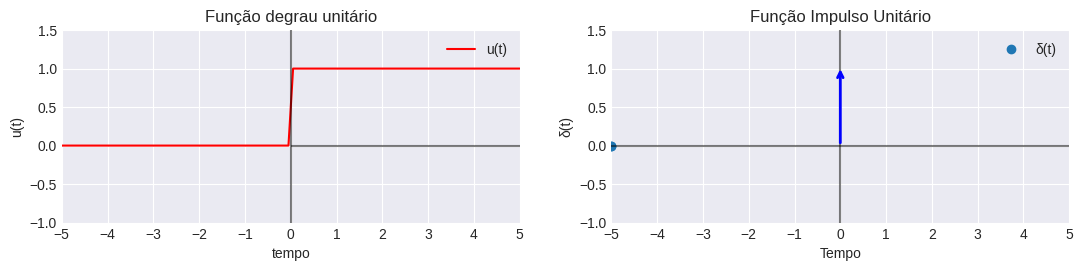

In [195]:
def u(t):
    if t < 0:
        return 0
    else:
        return 1

t = np.linspace(-5, 5, 100)
t_delta = np.linspace(-5, 5, 1)

# Configurando gráficos.
plt.style.use('seaborn-v0_8-darkgrid')
fig, axis = plt.subplots(1, 2, figsize = (13,2.5))

# Gráfico da função degrau unitário.
axis[0].plot(t, list(map(u, t)), color = "red", label = "u(t)")
axis[0].axis([-5, 5, -1, 1.5])
axis[0].set_xticks(np.arange(-5, 6, 1))
axis[0].hlines(0, 0, 5, 'k', alpha=0.5)
axis[0].vlines(0, -1, 1.5, 'k', alpha=0.5)
axis[0].set_title("Função degrau unitário")
axis[0].set_xlabel("tempo")
axis[0].set_ylabel("u(t)")
axis[0].legend(loc = "best")

# Gráfico da função impulso unitário.
impulse = np.zeros_like(t_delta)
impulse[t_delta == 0] = 1
axis[1].plot(t_delta, impulse, "o", label="δ(t)")
axis[1].stem(t_delta, impulse)
# Adicionando uma seta para cima
axis[1].annotate('', xy=(0, 1.03), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color='blue', lw=2))
axis[1].axis([-5, 5, -1, 1.5])
axis[1].set_xticks(np.arange(-5, 6, 1))
axis[1].hlines(0, -5, 5, 'k', alpha=0.5)
axis[1].vlines(0, -1, 1.5, 'k', alpha=0.5)
axis[1].set_title("Função Impulso Unitário")
axis[1].set_xlabel("Tempo")
axis[1].set_ylabel("δ(t)")
axis[1].legend(loc = "best")

plt.show()

A multiplição de uma função por impluso pode ser definida por:
$$
x(t)δ(t - t_o) = x(t_o) δ(t - t_o)
$$

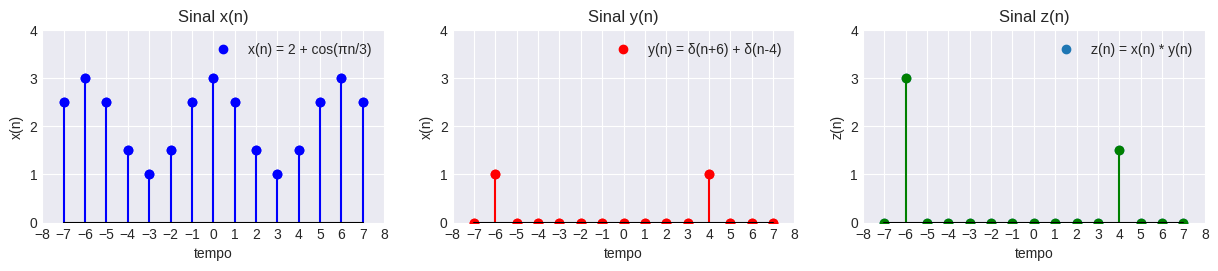

In [223]:
# Definindo os valores de n.
n = np.arange(-7, 8, 1)

# Definindo o sinal x(n).
x = lambda n : 2 + np.cos((np.pi * n) / 3)

# Definindo o sinal y(n) com função delta.
y = np.zeros_like(n)
# Definindo os valores de picos.
y[n == -6] = 1
y[n == 4] = 1

# Realizando a multiplicação dos sinais
z = lambda n : x(n) * y

# Plotando os gráficos
fig, axis = plt.subplots(1, 3, figsize=(15, 2.5), sharex=True)

# Gráfico de x(n)
axis[0].plot(n, x(n), "o", color = "blue", label='x(n) = 2 + cos(πn/3)')
axis[0].stem(n, x(n), linefmt='b-', markerfmt='bo', basefmt='k')
axis[0].axis([-8, 8, 0, 4])
axis[0].set_xticks(np.arange(-8, 9, 1))
axis[0].set_title("Sinal x(n)")
axis[0].set_xlabel("tempo")
axis[0].set_ylabel("x(n)")
axis[0].legend(loc='best')

# Gráfico de y(n)
axis[1].plot(n, y, "o", color = "red", label='y(n) = δ(n+6) + δ(n-4)')
axis[1].stem(n, y, linefmt='r-', markerfmt='ro', basefmt='k')
axis[1].axis([-8, 8, 0, 4])
axis[1].set_xticks(np.arange(-8, 9, 1))
axis[1].set_title("Sinal y(n)")
axis[1].set_xlabel("tempo")
axis[1].set_ylabel("x(n)")
axis[1].legend(loc='best')

# Gráfico gerado pela multiplicação: z(n) = x(n) * y(n)
axis[2].plot(n, z(n), "o", label='z(n) = x(n) * y(n)')
axis[2].stem(n, z(n), linefmt='g-', markerfmt='go', basefmt='k')
axis[2].axis([-8, 8, 0, 4])
axis[2].set_xticks(np.arange(-8, 9, 1))
axis[2].set_title("Sinal z(n)")
axis[2].set_xlabel("tempo")
axis[2].set_ylabel("z(n)")
axis[2].legend(loc='best')


plt.show()


Neste exemplo criamos uma sequência $x_n$  que é uma função cosseno modificada, colocamos um sinal com amplitude igual a 1 nos picos em $n = -6$ e $n = 4$ para representar as funções delta e  realizamos a multiplicação ponto a ponto entre $x(n)$ e $y(n)$, resultando em $z(n)$.
 $$x(t) = 2 + cos(\frac{π*n}{3}) \quad y(t) =  δ(n + 6) + δ(n - 4)$$
 Após a multiplicação encontramos a exepressão para $z(n)$:
 $$z(n) = x(-6)δ(n + 6) + x(4)δ(n - 4)$$
 De forma geral para tempo discreto:
$$x(n) =
\begin{equation}
  \sum_{k=-∞}^{∞} x(k)δ(n - k)
\end{equation}$$
Já para o tempo contínuo temos:
$$x(t) =
\begin{equation}
  \int_{-∞}^{∞} x(τ)δ(t - τ)dτ
\end{equation}
$$

### Referências:
---
1. **BROWN, J. W.; CHURCHILL, R. V.** *Complex Variables and Applications*. 8ª ed. New York: McGraw-Hill, 2009.
2. **Universidade Estadual de Campinas**. *Linearidade em Sinais e Sistemas*. Disponível em: [https://www.fee.unicamp.br/profs/peres/ia888/1s24/ia888_1s24.html](https://www.fee.unicamp.br/profs/peres/ia888/1s24/ia888_1s24.html). Acessado em 29 de Outubro de 2024.
3. Livro Alan V. Oppenheim
4. Repositorio do Francinildo
